### Installation

In [ ]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
    !pip install --no-deps --upgrade "torchao>=0.16.0"
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2
!pip install jiwer
!pip install einops addict easydict
!pip install matplotlib

### Unsloth

Let's prepare the OCR model

In [ ]:
from huggingface_hub import snapshot_download
snapshot_download("unsloth/DeepSeek-OCR", local_dir = "deepseek_ocr")

Fetching 20 files:   0%|          | 0/20 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

LICENSE: 0.00B [00:00, ?B/s]

configuration_deepseek_v2.py: 0.00B [00:00, ?B/s]

...

modeling_deepseekv2.py: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/801 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

'/teamspace/studios/this_studio/deepseek_ocr'

In [ ]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch
from transformers import AutoModel
import os
os.environ["UNSLOTH_WARN_UNINITIALIZED"] = '0'
# 4bit pre quantized models we support for 4x faster downloading + no OOMs.
fourbit_models = [
    "unsloth/Qwen3-VL-8B-Instruct-bnb-4bit", # Qwen 3 vision support
    "unsloth/Qwen3-VL-8B-Thinking-bnb-4bit",
    "unsloth/Qwen3-VL-32B-Instruct-bnb-4bit",
    "unsloth/Qwen3-VL-32B-Thinking-bnb-4bit",
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastVisionModel.from_pretrained(
    "./deepseek_ocr",
    load_in_4bit = False, # Use 4bit to reduce memory use. False for 16bit LoRA.
    auto_model = AutoModel,
    trust_remote_code = True,
    unsloth_force_compile = True,
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.


Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2026.5.2: Fast Deepseekocr patching. Transformers: 4.56.2.
   \\   /|    NVIDIA L40S. Num GPUs = 1. Max memory: 44.392 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


Some weights of DeepseekOCRForCausalLM were not initialized from the model checkpoint at ./deepseek_ocr and are newly initialized: ['model.vision_model.embeddings.position_ids']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### Let's Evaluate Deepseek-OCR Baseline Performance on Arabic Transcription

In [ ]:
from datasets import Dataset
from huggingface_hub import hf_hub_download, list_repo_files
import pandas as pd
import base64
from io import BytesIO
from PIL import Image

# ── List Amiri CSV files ──────────────────────────────────────────
all_files = list(list_repo_files("riotu-lab/SARD", repo_type="dataset"))
amiri_files = sorted([f for f in all_files if f.startswith("Amiri/") and f.endswith(".csv")])
print(f"Amiri CSV files found: {len(amiri_files)}")

# ── Download CSVs until we have 1000 rows ─────────────────────────
amiri_rows = []
for csv_file in amiri_files:
    local_path = hf_hub_download(
        repo_id="riotu-lab/SARD",
        filename=csv_file,
        repo_type="dataset"
    )
    df = pd.read_csv(local_path)
    amiri_rows.append(df)
    total = sum(len(r) for r in amiri_rows)
    print(f"✅ {csv_file}: {len(df)} rows | running total: {total}")
    if total >= 1000:
        break

amiri_df = pd.concat(amiri_rows, ignore_index=True).head(1000)
print(f"\nFinal rows: {len(amiri_df)}")
print(f"Columns: {list(amiri_df.columns)}")

# ── Decode base64 images ──────────────────────────────────────────
print("\nDecoding images...")
records = []
for i, (_, row) in enumerate(amiri_df.iterrows()):
    try:
        image_data = base64.b64decode(row["image_base64"])
        image = Image.open(BytesIO(image_data)).convert("RGB")
        image = image.resize((640, 640), Image.LANCZOS)  # resize to save RAM
        records.append({"image": image, "text": str(row["chunk"])})
    except:
        pass
    if (i + 1) % 100 == 0:
        print(f"  {i+1}/1000 decoded")

dataset = Dataset.from_list(records)
print(f"\n✅ Dataset ready: {len(dataset)} samples")

# ── Train/eval split ──────────────────────────────────────────────
split = dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split["train"]   # 900 samples
eval_dataset  = split["test"]    # 100 samples

print(f"Train: {len(train_dataset)} | Eval: {len(eval_dataset)}")

Amiri CSV files found: 133
✅ Amiri/dataset_Alukah_Arabic_font_Amiri_batch_0.csv: 4244 rows | running total: 4244

Final rows: 1000
Columns: ['image_name', 'chunk', 'font_name', 'image_base64', 'sample_id', 'article_link']

Decoding images...
  100/1000 decoded
  200/1000 decoded
  300/1000 decoded
  400/1000 decoded
  500/1000 decoded
  600/1000 decoded
  700/1000 decoded
  800/1000 decoded
  900/1000 decoded
  1000/1000 decoded

✅ Dataset ready: 1000 samples
Train: 900 | Eval: 100


In [ ]:
# Save an image that will not be used during training for evaluation purposes
dataset[500]['image'].save("your_image.jpg")

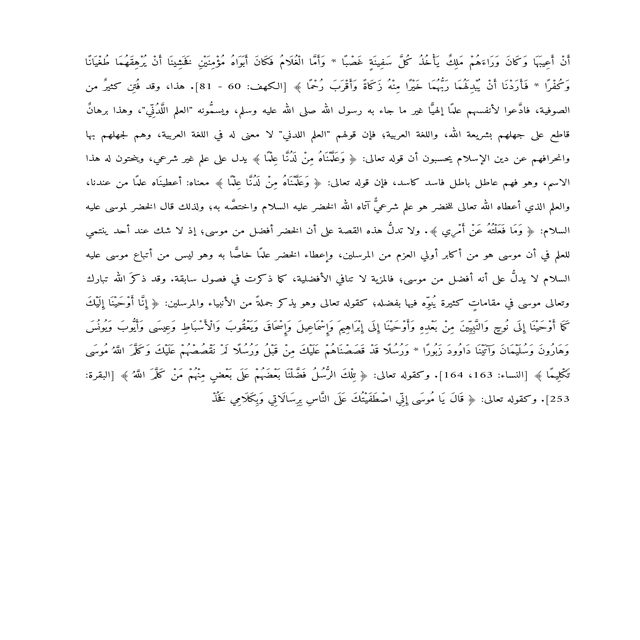

In [ ]:
dataset[500]['image']

In [ ]:
# prompt = "<image>\nFree OCR. "
prompt = "<image>\nFree OCR. "
image_file = 'your_image.jpg'
output_path = 'your/output/dir'
# infer(self, tokenizer, prompt = '', image_file = '', output_path = ' ', base_size = 1024, image_size = 640, crop_mode = True, test_compress = False, save_results = False):

# Tiny: base_size = 512, image_size = 512, crop_mode = False
# Small: base_size = 640, image_size = 640, crop_mode = False
# Base: base_size = 1024, image_size = 1024, crop_mode = False
# Large: base_size = 1280, image_size = 1280, crop_mode = False

# Gundam: base_size = 1024, image_size = 640, crop_mode = True

res = model.infer(tokenizer, prompt = prompt, image_file = image_file, output_path = output_path, base_size = 1024, image_size = 640, crop_mode = True, save_results = True, test_compress = False)

أن أُعْبَأَ بُوَكَانَ وَزَاءَهُمْ مَلِكٌ يَأْخُذُ كُلَّ سَفِينَةٍ عَصْبًا * وَأَمَّا الْفَلَامُ كَانَ أَيَّاهُ مُؤْمِنِينَ فَلْيَبْدَأَ أَنْ يُرْهَقَهُمَا لَعْنَيَا
وَكَفَرَ * فَأَرَدْنَا أَنْ يُبْدِئُنَا رَبُّنَا مِمَّا رَزَقَ وَأَقْرَبَ رُحَمًا {الكهف: 60-81}. هذا، وقد فُتِنَ كثيرٌ من
الصوفية، فادعوا لأنفسهم على إيمانا على ما جاء به رسول الله صلى الله عليه وسلم، ويُسْوِهُ "الْعَلَمُ الْمُذْقَى"، وهذا يرهان
قاطع على جهلهم بشرية الله، واللغة العربية، فإن قومهم "الْعَلَمُ الْمُذْقَى" لا معنى له في اللغة العربية، وهم جعلهم بها
واخرافهم عن دين الإسلام يبينون أن قوله تعالى: {وَعَلَيْتَنَا مِنْ لَدُنْهَا إِلَيْهِ} يدل على غير شرعي، ويخوض له هذا
الاسم، وهو فهم عاطل بالصاف كاسد، فإن قوله تعالى: {وَعَلَيْتَنَا مِنْ لَدُنْهَإِلَيْهِ} معناه: أعطيتها على من عندنا،
والعلم الذي أعطاه الله تعالى لخضر هو على شرعي أثناء الله الخضر عليه السلام واختتمه به، ولذلك قال الخضر لموسى عليه
السلام: {وَمَا فَعَلْتُهُ عَنْ أَمْرِي}. ولا تدل هذه القصة على أن الخضر أفضل من موسى، إذ لا شك عند أحد ينتمي
للعلم في أن م

image: 0it [00:00, ?it/s]
other: 0it [00:00, ?it/s]


In [ ]:
dataset[500]["text"]

'أَنْ أَعِيبَهَا وَكَانَ وَرَاءَهُمْ مَلِكٌ يَأْخُذُ كُلَّ سَفِينَةٍ غَصْبًا * وَأَمَّا الْغُلَامُ فَكَانَ أَبَوَاهُ مُؤْمِنَيْنِ فَخَشِينَا أَنْ يُرْهِقَهُمَا طُغْيَانًا وَكُفْرًا * فَأَرَدْنَا أَنْ يُبْدِلَهُمَا رَبُّهُمَا خَيْرًا مِنْهُ زَكَاةً وَأَقْرَبَ رُحْمًا ﴾ [الكهف: 60 - 81]. هذا، وقد فُتِن كثيرٌ من الصوفية، فادَّعوا لأنفسهم علمًا إلهيًّا غير ما جاء به رسول الله صلى الله عليه وسلم، ويسمُّونه "العلم اللَّدُنِّي"، وهذا برهانٌ قاطع على جهلهم بشريعة الله، واللغة العربية؛ فإن قولهم "العلم اللدني" لا معنى له في اللغة العربية، وهم لجهلهم بها وانحرافهم عن دين الإسلام يحسبون أن قوله تعالى: ﴿ وَعَلَّمْنَاهُ مِنْ لَدُنَّا عِلْمًا ﴾ يدل على علم غير شرعي، وينحتون له هذا الاسم، وهو فهم عاطل باطل فاسد كاسد، فإن قوله تعالى: ﴿ وَعَلَّمْنَاهُ مِنْ لَدُنَّا عِلْمًا ﴾ معناه: أعطينَاه علمًا من عندنا، والعلم الذي أعطاه الله تعالى للخضر هو علم شرعيٌّ آتاه الله الخضر عليه السلام واختصَّه به؛ ولذلك قال الخضر لموسى عليه السلام: ﴿ وَمَا فَعَلْتُهُ عَنْ أَمْرِي ﴾. ولا تدلُّ هذه القصة على أن الخضر أفضل م

<h3>Baseline Model Performance: ~60% accuracy </h3>

# Let's finetune Deepseek-OCR !

We now add LoRA adapters for parameter efficient finetuning - this allows us to only efficiently train 1% of all parameters.

In [ ]:
model = FastVisionModel.get_peft_model(
    model,
    target_modules = [
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],

    r = 16,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 16,  # Recommended alpha == r at least
    lora_dropout = 0.05,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
    # target_modules = "all-linear", # Optional now! Can specify a list if needed
)

<a name="Data"></a>
### Data Prep

You can access the dataset [here](https://huggingface.co/datasets/riotu-lab/SARD).

To format the dataset, all vision finetuning tasks should be formatted as follows:

```python
[
{ "role": "<|User|>",
  "content": "",
  "images": []
},
{ "role": "<|Assistant|>",
  "content": ""
},
]
```

In [ ]:
instruction = "<image>\nFree OCR. "

def convert_to_conversation(sample):
    conversation = [
        {
            "role": "<|User|>",
            "content": instruction,
            "images": [sample['image']],
        },
        {
            "role": "<|Assistant|>",
            "content": sample['text'],
        },
    ]
    return {"messages": conversation}

converted_train = train_dataset.map(convert_to_conversation)
converted_eval  = eval_dataset.map(convert_to_conversation)

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

In [ ]:
converted_train[0]

In [ ]:
# @title Create datacollator

import torch
import math
from dataclasses import dataclass
from typing import Dict, List, Any, Tuple
from PIL import Image, ImageOps
from torch.nn.utils.rnn import pad_sequence
import io

from deepseek_ocr.modeling_deepseekocr import (
    format_messages,
    text_encode,
    BasicImageTransform,
    dynamic_preprocess,
)

@dataclass
class DeepSeekOCRDataCollator:
    """
    Args:
        tokenizer: Tokenizer
        model: Model
        image_size: Size for image patches (default: 640)
        base_size: Size for global view (default: 1024)
        crop_mode: Whether to use dynamic cropping for large images
        train_on_responses_only: If True, only train on assistant responses (mask user prompts)
    """
    tokenizer: Any
    model: Any
    image_size: int = 640
    base_size: int = 1024
    crop_mode: bool = True
    image_token_id: int = 128815
    train_on_responses_only: bool = True

    def __init__(
        self,
        tokenizer,
        model,
        image_size: int = 640,
        base_size: int = 1024,
        crop_mode: bool = True,
        train_on_responses_only: bool = True,
    ):
        self.tokenizer = tokenizer
        self.model = model
        self.image_size = image_size
        self.base_size = base_size
        self.crop_mode = crop_mode
        self.image_token_id = 128815
        self.dtype = model.dtype  # Get dtype from model
        self.train_on_responses_only = train_on_responses_only

        self.image_transform = BasicImageTransform(
            mean = (0.5, 0.5, 0.5),
            std = (0.5, 0.5, 0.5),
            normalize = True
        )
        self.patch_size = 16
        self.downsample_ratio = 4

        # Get BOS token ID from tokenizer
        if hasattr(tokenizer, 'bos_token_id') and tokenizer.bos_token_id is not None:
            self.bos_id = tokenizer.bos_token_id
        else:
            self.bos_id = 0
            print(f"Warning: tokenizer has no bos_token_id, using default: {self.bos_id}")

    def deserialize_image(self, image_data) -> Image.Image:
        """Convert image data (bytes dict or PIL Image) to PIL Image in RGB mode"""
        if isinstance(image_data, Image.Image):
            return image_data.convert("RGB")
        elif isinstance(image_data, dict) and 'bytes' in image_data:
            image_bytes = image_data['bytes']
            image = Image.open(io.BytesIO(image_bytes))
            return image.convert("RGB")
        else:
            raise ValueError(f"Unsupported image format: {type(image_data)}")

    def calculate_image_token_count(self, image: Image.Image, crop_ratio: Tuple[int, int]) -> int:
        """Calculate the number of tokens this image will generate"""
        num_queries = math.ceil((self.image_size // self.patch_size) / self.downsample_ratio)
        num_queries_base = math.ceil((self.base_size // self.patch_size) / self.downsample_ratio)

        width_crop_num, height_crop_num = crop_ratio

        if self.crop_mode:
            img_tokens = num_queries_base * num_queries_base + 1
            if width_crop_num > 1 or height_crop_num > 1:
                img_tokens += (num_queries * width_crop_num + 1) * (num_queries * height_crop_num)
        else:
            img_tokens = num_queries * num_queries + 1

        return img_tokens

    def process_image(self, image: Image.Image) -> Tuple[List, List, List, List, Tuple[int, int]]:
        """
        Process a single image based on crop_mode and size thresholds

        Returns:
            Tuple of (images_list, images_crop_list, images_spatial_crop, tokenized_image, crop_ratio)
        """
        images_list = []
        images_crop_list = []
        images_spatial_crop = []

        if self.crop_mode:
            # Determine crop ratio based on image size
            if image.size[0] <= 640 and image.size[1] <= 640:
                crop_ratio = (1, 1)
                images_crop_raw = []
            else:
                images_crop_raw, crop_ratio = dynamic_preprocess(
                    image, min_num = 2, max_num = 9,
                    image_size = self.image_size, use_thumbnail = False
                )

            # Process global view with padding
            global_view = ImageOps.pad(
                image, (self.base_size, self.base_size),
                color = tuple(int(x * 255) for x in self.image_transform.mean)
            )
            images_list.append(self.image_transform(global_view).to(self.dtype))

            width_crop_num, height_crop_num = crop_ratio
            images_spatial_crop.append([width_crop_num, height_crop_num])

            # Process local views (crops) if applicable
            if width_crop_num > 1 or height_crop_num > 1:
                for crop_img in images_crop_raw:
                    images_crop_list.append(
                        self.image_transform(crop_img).to(self.dtype)
                    )

            # Calculate image tokens
            num_queries = math.ceil((self.image_size // self.patch_size) / self.downsample_ratio)
            num_queries_base = math.ceil((self.base_size // self.patch_size) / self.downsample_ratio)

            tokenized_image = ([self.image_token_id] * num_queries_base + [self.image_token_id]) * num_queries_base
            tokenized_image += [self.image_token_id]

            if width_crop_num > 1 or height_crop_num > 1:
                tokenized_image += ([self.image_token_id] * (num_queries * width_crop_num) + [self.image_token_id]) * (
                    num_queries * height_crop_num)

        else:  # crop_mode = False
            crop_ratio = (1, 1)
            images_spatial_crop.append([1, 1])

            # For smaller base sizes, resize; for larger, pad
            if self.base_size <= 640:
                resized_image = image.resize((self.base_size, self.base_size), Image.LANCZOS)
                images_list.append(self.image_transform(resized_image).to(self.dtype))
            else:
                global_view = ImageOps.pad(
                    image, (self.base_size, self.base_size),
                    color = tuple(int(x * 255) for x in self.image_transform.mean)
                )
                images_list.append(self.image_transform(global_view).to(self.dtype))

            num_queries = math.ceil((self.base_size // self.patch_size) / self.downsample_ratio)
            tokenized_image = ([self.image_token_id] * num_queries + [self.image_token_id]) * num_queries
            tokenized_image += [self.image_token_id]

        return images_list, images_crop_list, images_spatial_crop, tokenized_image, crop_ratio

    def process_single_sample(self, messages: List[Dict]) -> Dict[str, Any]:
            """
            Process a single conversation into model inputs.
            """

            # --- 1. Setup ---
            images = []
            for message in messages:
                if "images" in message and message["images"]:
                    for img_data in message["images"]:
                        if img_data is not None:
                            pil_image = self.deserialize_image(img_data)
                            images.append(pil_image)

            if not images:
                raise ValueError("No images found in sample. Please ensure all samples contain images.")

            tokenized_str = []
            images_seq_mask = []
            images_list, images_crop_list, images_spatial_crop = [], [], []

            prompt_token_count = -1 # Index to start training
            assistant_started = False
            image_idx = 0

            # Add BOS token at the very beginning
            tokenized_str.append(self.bos_id)
            images_seq_mask.append(False)

            for message in messages:
                role = message["role"]
                content = message["content"]

                # Check if this is the assistant's turn
                if role == "<|Assistant|>":
                    if not assistant_started:
                        # This is the split point. All tokens added *so far*
                        # are part of the prompt.
                        prompt_token_count = len(tokenized_str)
                        assistant_started = True

                    # Append the EOS token string to the *end* of assistant content
                    content = f"{content.strip()} {self.tokenizer.eos_token}"

                # Split this message's content by the image token
                text_splits = content.split('<image>')

                for i, text_sep in enumerate(text_splits):
                    # Tokenize the text part
                    tokenized_sep = text_encode(self.tokenizer, text_sep, bos = False, eos = False)
                    tokenized_str.extend(tokenized_sep)
                    images_seq_mask.extend([False] * len(tokenized_sep))

                    # If this text is followed by an <image> tag
                    if i < len(text_splits) - 1:
                        if image_idx >= len(images):
                            raise ValueError(
                                f"Data mismatch: Found '<image>' token but no corresponding image."
                            )

                        # Process the image
                        image = images[image_idx]
                        img_list, crop_list, spatial_crop, tok_img, _ = self.process_image(image)

                        images_list.extend(img_list)
                        images_crop_list.extend(crop_list)
                        images_spatial_crop.extend(spatial_crop)

                        # Add image placeholder tokens
                        tokenized_str.extend(tok_img)
                        images_seq_mask.extend([True] * len(tok_img))

                        image_idx += 1 # Move to the next image

            # --- 3. Validation and Final Prep ---
            if image_idx != len(images):
                raise ValueError(
                    f"Data mismatch: Found {len(images)} images but only {image_idx} '<image>' tokens were used."
                )

            # If we never found an assistant message, we're in a weird state
            # (e.g., user-only prompt). We mask everything.
            if not assistant_started:
                print("Warning: No assistant message found in sample. Masking all tokens.")
                prompt_token_count = len(tokenized_str)

            # Prepare image tensors
            images_ori = torch.stack(images_list, dim = 0)
            images_spatial_crop_tensor = torch.tensor(images_spatial_crop, dtype = torch.long)

            if images_crop_list:
                images_crop = torch.stack(images_crop_list, dim = 0)
            else:
                images_crop = torch.zeros((1, 3, self.base_size, self.base_size), dtype = self.dtype)

            return {
                "input_ids": torch.tensor(tokenized_str, dtype = torch.long),
                "images_seq_mask": torch.tensor(images_seq_mask, dtype = torch.bool),
                "images_ori": images_ori,
                "images_crop": images_crop,
                "images_spatial_crop": images_spatial_crop_tensor,
                "prompt_token_count": prompt_token_count, # This is now accurate
            }

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        """Collate batch of samples"""
        batch_data = []

        # Process each sample
        for feature in features:
            try:
                processed = self.process_single_sample(feature['messages'])
                batch_data.append(processed)
            except Exception as e:
                print(f"Error processing sample: {e}")
                continue

        if not batch_data:
            raise ValueError("No valid samples in batch")

        # Extract lists
        input_ids_list = [item['input_ids'] for item in batch_data]
        images_seq_mask_list = [item['images_seq_mask'] for item in batch_data]
        prompt_token_counts = [item['prompt_token_count'] for item in batch_data]

        # Pad sequences
        input_ids = pad_sequence(input_ids_list, batch_first = True, padding_value = self.tokenizer.pad_token_id)
        images_seq_mask = pad_sequence(images_seq_mask_list, batch_first = True, padding_value = False)

        # Create labels
        labels = input_ids.clone()

        # Mask padding tokens
        labels[labels == self.tokenizer.pad_token_id] = -100

        # Mask image tokens (model shouldn't predict these)
        labels[images_seq_mask] = -100

        # Mask user prompt tokens when train_on_responses_only = True (only train on assistant responses)
        if self.train_on_responses_only:
            for idx, prompt_count in enumerate(prompt_token_counts):
                if prompt_count > 0:
                    labels[idx, :prompt_count] = -100

        # Create attention mask
        attention_mask = (input_ids != self.tokenizer.pad_token_id).long()

        # Prepare images batch (list of tuples)
        images_batch = []
        for item in batch_data:
            images_batch.append((item['images_crop'], item['images_ori']))

        # Stack spatial crop info
        images_spatial_crop = torch.cat([item['images_spatial_crop'] for item in batch_data], dim = 0)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
            "images": images_batch,
            "images_seq_mask": images_seq_mask,
            "images_spatial_crop": images_spatial_crop,
        }

<a name="Train"></a>
### Train the model
Now let's train our model. We do 60 steps to speed things up.

In [ ]:
from transformers import Trainer, TrainingArguments, EarlyStoppingCallback
from unsloth import is_bf16_supported

FastVisionModel.for_training(model)

data_collator = DeepSeekOCRDataCollator(
    tokenizer=tokenizer,
    model=model,
    image_size=640,
    base_size=1024,
    crop_mode=True,
    train_on_responses_only=True,
)

trainer = Trainer(
    model=model,
    tokenizer=tokenizer,
    data_collator=data_collator,
    train_dataset=converted_train,
    eval_dataset=converted_eval,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    args=TrainingArguments(
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        warmup_steps=5,
        max_steps=60,
        learning_rate=2e-4,
        fp16=not is_bf16_supported(),
        bf16=is_bf16_supported(),
        logging_steps=10,
        save_steps=20,
        eval_strategy="steps",
        eval_steps=20,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        output_dir="arabic_deepseek_ocr_v2",
        remove_unused_columns=False,
        report_to="none",
        optim="adamw_8bit",
        weight_decay=0.001,
        lr_scheduler_type="linear",
        seed=3407,
        dataloader_num_workers=2,
    ),
)

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/unsloth/models/_utils.py:2349: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  _original_trainer_init(self, *args, **kwargs)


In [ ]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = NVIDIA L40S. Max memory = 44.392 GB.
6.719 GB of memory reserved.


In [ ]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 900 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 77,509,632 of 3,413,615,872 (2.27% trained)
Unsloth: Not an error, but DeepseekOCRForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
20,0.268600,0.257980
40,0.213800,0.233563
60,0.219000,0.226661


You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.
You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.
You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.


In [ ]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

534.854 seconds used for training.
8.91 minutes used for training.
Peak reserved memory = 30.393 GB.
Peak reserved memory for training = 23.674 GB.
Peak reserved memory % of max memory = 68.465 %.
Peak reserved memory for training % of max memory = 53.329 %.


<a name="Save"></a>
### Saving, loading finetuned models
To save the final model as LoRA adapters, either use Hugging Face's `push_to_hub` for an online save or `save_pretrained` for a local save.

**[NOTE]** This ONLY saves the LoRA adapters, and not the full model. To save to 16bit or GGUF, scroll down!

In [ ]:
model.save_pretrained("deepseek_ocr_lora")  # Local saving
tokenizer.save_pretrained("deepseek_ocr_lora")
# model.push_to_hub("your_name/deepseek_ocr_lora", token = "YOUR_HF_TOKEN") # Online saving
# tokenizer.push_to_hub("your_name/deepseek_ocr_lora", token = "YOUR_HF_TOKEN") # Online saving

You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.


('deepseek_ocr_lora/tokenizer_config.json',
 'deepseek_ocr_lora/special_tokens_map.json',
 'deepseek_ocr_lora/tokenizer.json')

Now if you want to load the LoRA adapters we just saved for inference, set `False` to `True`:

# INFERENCE

Let's run the model

In [ ]:
if False:
    from unsloth import FastVisionModel
    model, tokenizer = FastVisionModel.from_pretrained(
        model_name = "deepseek_ocr_lora", # YOUR MODEL YOU USED FOR TRAINING
        load_in_4bit = False, # Use 4bit to reduce memory use. False for 16bit LoRA.
        auto_model = AutoModel,
        trust_remote_code = True,
        unsloth_force_compile = True,
        use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
    )
    FastVisionModel.for_inference(model) # Enable for inference!

prompt = "<image>\nFree OCR. "
image_file = 'your_image.jpg'
output_path = 'your/output/dir'

# Tiny: base_size = 512, image_size = 512, crop_mode = False
# Small: base_size = 640, image_size = 640, crop_mode = False
# Base: base_size = 1024, image_size = 1024, crop_mode = False
# Large: base_size = 1280, image_size = 1280, crop_mode = False

# Gundam: base_size = 1024, image_size = 640, crop_mode = True

res = model.infer(tokenizer, prompt = prompt, image_file = image_file,
    output_path = output_path,
    image_size = 640,
    base_size = 1024,
    crop_mode = True,
    save_results = True,
    test_compress = False)

أَن أُعِيبًا وَكَانَ وَرَاءَهُمْ مَلِكٌ يَأْخُذُ كُلَّ سَفِينَةٍ غَضَبًا * وَأَمَّا الْفَلَامُ فَكَانَ أَيَّارَهُ مُؤْمِنَيْنِ نَفْقِينَا أَنْ يُرْهَقَهُمَا لَطِنَآنا وَكُفْرًا * فَأَرَدْنَآ أَنْ يُدِيقُمَا رَبُّهُمَا خَيْرًا مِنْهُ زَكَاةً وَأَقْرَبَ رُحَمًا ﴾ [الكهف: 60 - 81]. هذا، وقد فمَّن كثيرٌ من الصوفية، فادَّعوا لأنفسهم علمًا إلهيًّا غير ما جاء به رسول الله صلى الله عليه وسلم، ويُسُلُوه "العلمُ الدُّنْيَى"، وهذا برهانٌ قاطع على جهلهم بشريعة الله، واللغة العربية، فإن قوهلم "العلم اللدني" لا معنى له في اللغة العربية، وهم لجهلهم بها واخرافهم عن دين الإسلام يحسبون أن قوله تعالى: ﴿ وَعَلِمْتَنَاهُ مِنْ لِدُنْآ عِلْمًا ﴾ يدل على علم غير شرعي، ويختون له هذا الاسم، وهو فهم عاطل باطل فاسد كاسد، فإن قوله تعالى: ﴿ وَعَلِمْتَنَاهُ مِنْ لِنُدُنْآ عِلْمًا ﴾ معناه: أعطيتَاه علمًا من عندنا، والعلم الذي أعطاه الله تعالى لخفض هو علم شرعيٌ أثناء الله الخضر عليه السلام واختصَّمه به، ولذلك قال الخضر لموسى عليه السلام: ﴿ وَمَا فَعَلْتُهُ عَنْ أَمْرِي ﴾. ولا تدنُّ هذه القصة على أن الخضر أفضل من موسى،

And we are done! With just 60 steps we got 85% accuracy.